# Chargement de donnée

In [ ]:
import pandas as pd

base_url = "https://raw.githubusercontent.com/maistro-ispm/atlantic-haven/refs/heads/main/ressources/"
data_dict_url = base_url + "data_dictionary.csv"
train_data_url = base_url + "reservations_train.csv"

df = pd.read_csv(train_data_url)

# Analyse de donnée (EDT)

In [ ]:

df.head()

,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,...,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,...,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,...,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,...,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,...,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,...,0,0,2.0,1,0,0,0,0,NaN,0


In [ ]:
df.describe()

,categorie_hotel,delai_reservation_jours,nuits,adultes,enfants,chambres,prix_moyen_nuit_eur,remise_pct,montant_total_eur,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,reservation_annulee
count,8000.000000,8000.000000,8000.000000,8000.000000,7645.000000,8000.000000,7807.000000,8000.000000,8000.000000,8000.000000,8000.000000,7843.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,3.832500,41.379625,4.203375,2.086125,0.529235,1.266875,201.473548,4.999625,1009.584740,2.416875,0.341250,0.917124,0.327875,0.323000,0.113250,0.436125,0.283625,0.258375
std,0.705873,49.232410,2.524492,0.914364,0.943367,0.664423,62.550478,3.649629,879.585635,3.785879,0.602573,0.887739,0.617795,1.787686,0.316918,0.495934,0.450785,0.437769
min,3.000000,1.000000,1.000000,1.000000,0.000000,1.000000,75.250000,0.000000,85.440000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,16.000000,2.000000,2.000000,0.000000,1.000000,158.945000,2.000000,475.615000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,29.000000,4.000000,2.000000,0.000000,1.000000,191.580000,5.000000,786.950000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,49.000000,6.000000,2.000000,1.000000,1.000000,233.210000,7.000000,1252.420000,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,5.000000,584.000000,30.000000,6.000000,3.000000,4.000000,848.420000,18.000000,13509.190000,12.000000,3.000000,4.000000,4.000000,15.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   reservation_id             8000 non-null   object 
 1   date_reservation           8000 non-null   object 
 2   date_arrivee               8000 non-null   object 
 3   region_hotel               8000 non-null   object 
 4   ville                      8000 non-null   object 
 5   type_destination           8000 non-null   object 
 6   hotel_id                   8000 non-null   object 
 7   categorie_hotel            8000 non-null   int64  
 8   segment_client             8000 non-null   object 
 9   marche_origine             7809 non-null   object 
 10  canal_reservation          8000 non-null   object 
 11  moyen_transport            8000 non-null   object 
 12  delai_reservation_jours    8000 non-null   int64  
 13  nuits                      8000 non-null   int64

In [ ]:
print("total: ", df.size)
print("colonnes manquantes: ", df.columns[df.isna().any()].tolist())
print("ligne avec colonne manquante: ", df.isnull().any(axis=1).sum())

total:  272000
colonnes manquantes:  ['marche_origine', 'enfants', 'prix_moyen_nuit_eur', 'demandes_speciales', 'agent_id']
ligne avec colonne manquante:  3830


# Completer les données manquantes par des valeurs par défaut

In [ ]:
import numpy as np
import pandas as pd # Ensure pandas is imported for pd.to_numeric

# Correctly fill missing values for 'enfants' (numerical) with 0
df["enfants"] = df["enfants"].fillna(0)

df["agent_id"] = df["agent_id"].fillna("AG0")
df["agent_id"] = df["agent_id"].astype('category')

df["marche_origine"] = df["marche_origine"].fillna("Unknown")
df["marche_origine"] = df["marche_origine"].astype('category')

df["prix_moyen_nuit_eur"] = pd.to_numeric(df["prix_moyen_nuit_eur"], errors='coerce')
df["prix_moyen_nuit_eur"] = df["prix_moyen_nuit_eur"].fillna(df["prix_moyen_nuit_eur"].median())

df["demandes_speciales"] = df["demandes_speciales"].fillna(0)

In [ ]:
print("ligne avec colonne manquante: ", df.isnull().any(axis=1).sum())

ligne avec colonne manquante:  0


# Plots

Correlation of numerical features with 'reservation_annulee':
delai_reservation_jours      0.110531
modifications_reservation    0.059761
chambres                     0.049157
adultes                      0.038409
montant_total_eur            0.037113
enfants                      0.033095
prix_moyen_nuit_eur          0.026115
nuits                        0.008781
categorie_hotel              0.008181
evenement_majeur             0.005328
arrivee_weekend              0.003641
haute_saison_regionale      -0.005453
annulations_passees         -0.011547
jours_liste_attente         -0.013521
reservations_passees        -0.018079
demandes_speciales          -0.054498
remise_pct                  -0.055104
dtype: float64


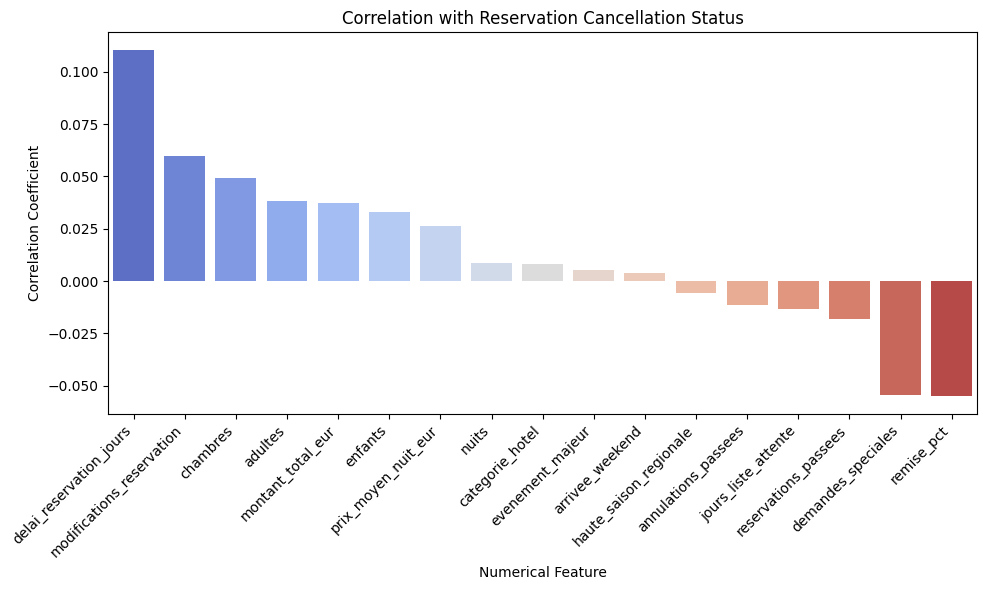

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select numerical columns (excluding the target itself)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'reservation_annulee' in numerical_cols:
    numerical_cols.remove('reservation_annulee')

# Calculate correlation with the target variable
correlations = df[numerical_cols].corrwith(df['reservation_annulee']).sort_values(ascending=False)

print("Correlation of numerical features with 'reservation_annulee':")
print(correlations)

# Visualize correlations
plt.figure(figsize=(10, 6))
sns.barplot(
    x=correlations.index,
    y=correlations.values,
    hue=correlations.index, # Fix: Assign x variable to hue
    legend=False,           # Fix: Hide redundant legend
    palette='coolwarm'
)
plt.title('Correlation with Reservation Cancellation Status')
plt.xlabel('Numerical Feature')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Prise en charge des valeurs non numériques

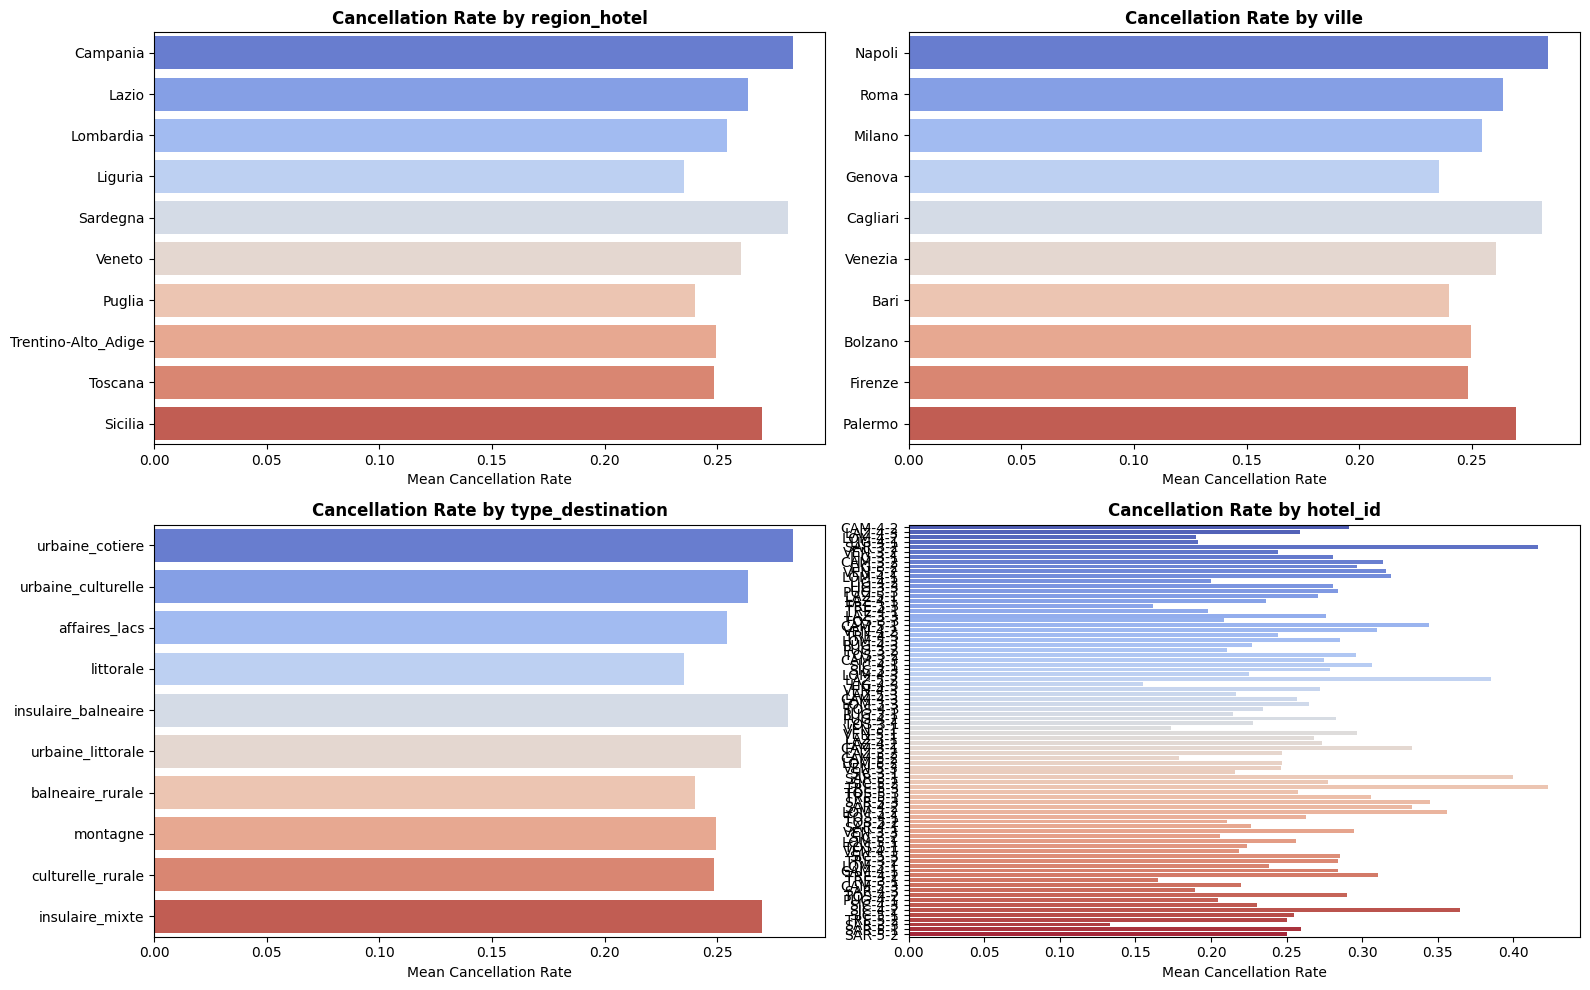

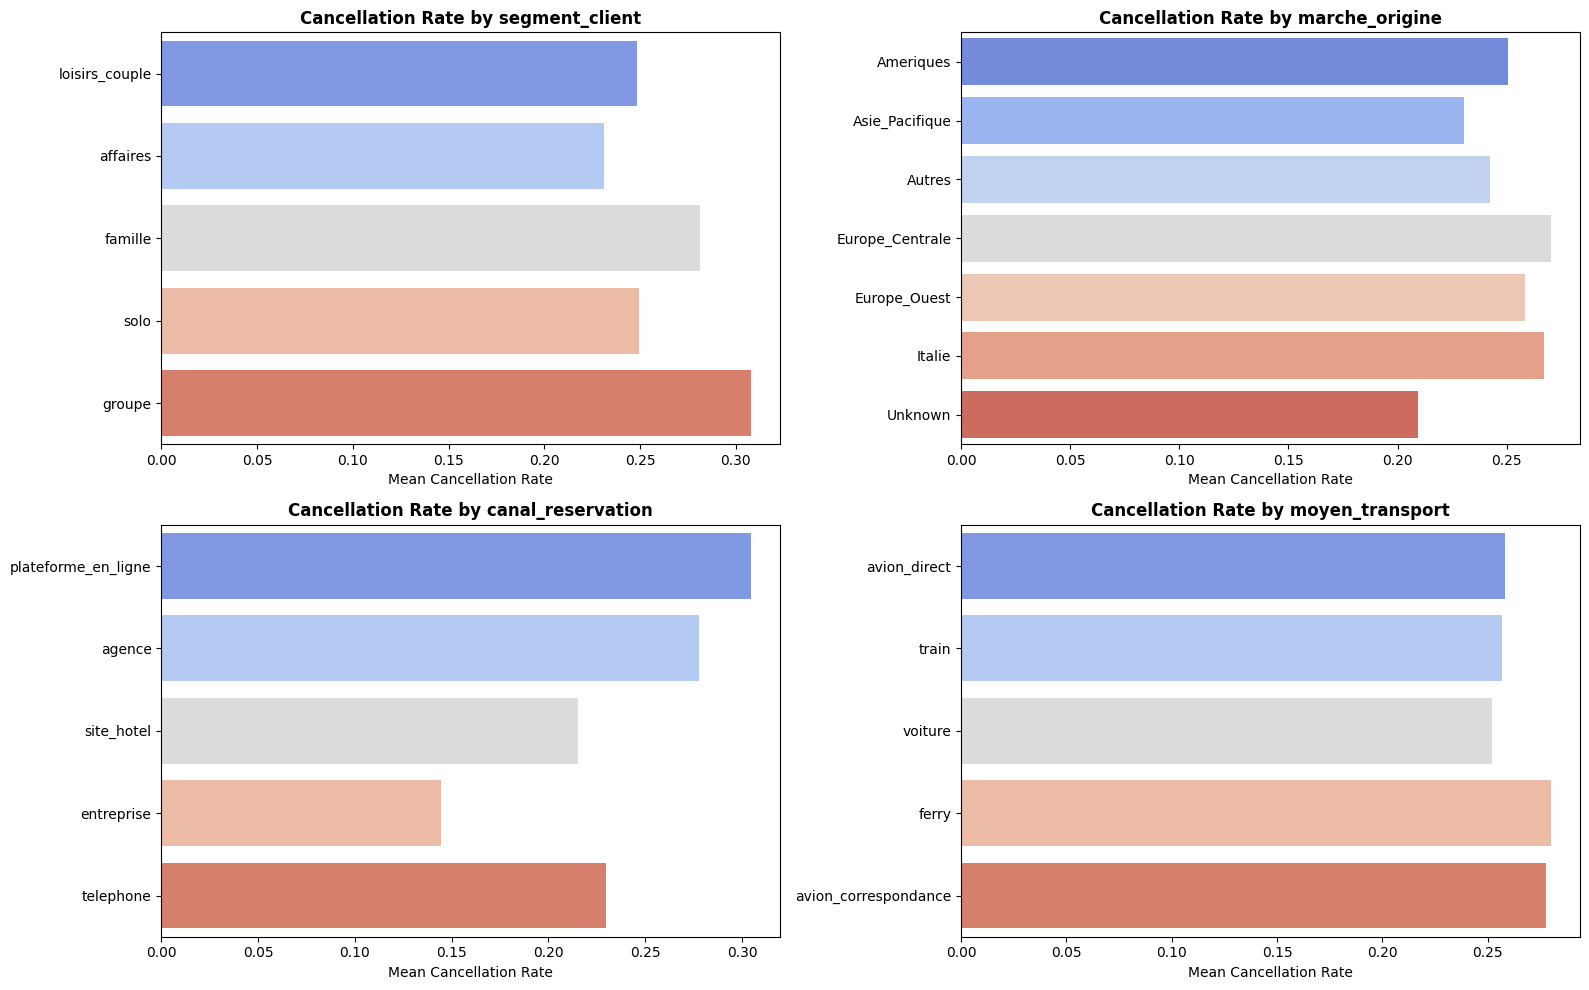

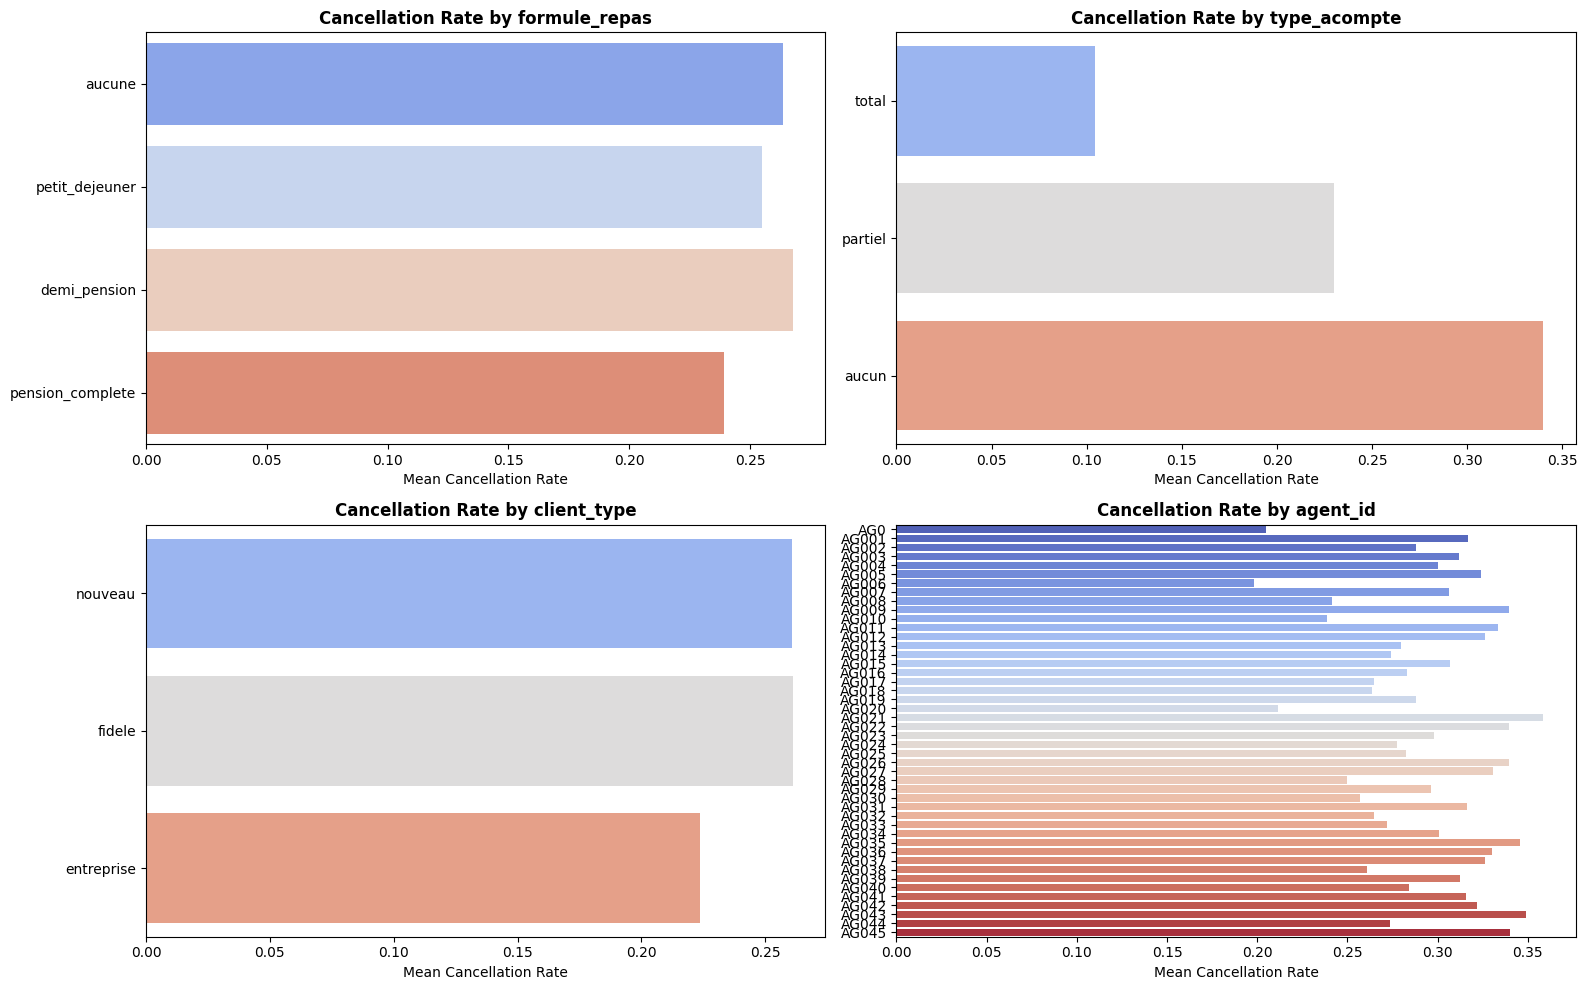

In [ ]:
categorical_cols = [
    "region_hotel", "ville", "type_destination", "hotel_id",
    "segment_client", "marche_origine", "canal_reservation",
    "moyen_transport", "formule_repas", "type_acompte",
    "client_type", "agent_id"
]

batch_size = 4
nrows, ncols = 2, 2

for i in range(0, len(categorical_cols), batch_size):
    batch = categorical_cols[i : i + batch_size]

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 10))
    axes = axes.flatten()

    for j, col in enumerate(batch):
        sns.barplot(
            data=df,
            x='reservation_annulee',
            y=col,
            hue=col,
            legend=False,
            ax=axes[j],
            errorbar=None,
            palette='coolwarm',
            orient='h'
        )
        axes[j].set_title(f"Cancellation Rate by {col}", fontsize=12, fontweight='bold')
        axes[j].set_xlabel("Mean Cancellation Rate")
        axes[j].set_ylabel("")

    for k in range(len(batch), len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

# Entrainement avec une Logistique Regression

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [ ]:
df_copie = df.copy()

In [ ]:
target = 'reservation_annulee'
X = df_copie.drop(columns=[target])
y = df_copie[target]
print("X : ", X.shape)
print("y : ", y.shape)

X :  (8000, 33)
y :  (8000,)


In [ ]:
# 3. TRAITEMENT DES DATES
# ============================================================

# Conversion en datetime
X["date_reservation"] = pd.to_datetime(
    X["date_reservation"],
    errors="coerce"
)

X["date_arrivee"] = pd.to_datetime(
    X["date_arrivee"],
    errors="coerce"
)

# --- Date de réservation ---
X["reservation_annee"] = X["date_reservation"].dt.year
X["reservation_mois"] = X["date_reservation"].dt.month
X["reservation_jour"] = X["date_reservation"].dt.day
X["reservation_jour_semaine"] = X["date_reservation"].dt.dayofweek

# --- Date d'arrivée ---
X["arrivee_annee"] = X["date_arrivee"].dt.year
X["arrivee_mois"] = X["date_arrivee"].dt.month
X["arrivee_jour"] = X["date_arrivee"].dt.day
X["arrivee_jour_semaine"] = X["date_arrivee"].dt.dayofweek

# Les dates originales ne sont plus nécessaires
X = X.drop(
    columns=[
        "date_reservation",
        "date_arrivee"
    ]
)

X = X.drop(columns=["reservation_id"])

# Création des données de train et test

In [ ]:
# 5. TRAIN / TEST SPLIT
# ============================================================

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain :", X_train.shape)
print("Test  :", X_test.shape)


Train : (6400, 206)
Test  : (1600, 206)


# Entrainement avec la Regression Logistique des données sans optimisation

In [ ]:
scaler = StandardScaler()

X_train_transformed = scaler.fit_transform(X_train)

X_test_transformed = scaler.transform(X_test)

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
model.fit(
    X_train_transformed,
    y_train
)
score = model.score(
    X_test_transformed,
    y_test
)
print("Score :", score)
y_pred = model.predict(
    X_test_transformed
)
print("Prédictions :")

# --- Calcul des métriques ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# --- Affichage des résultats ---
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Score : 0.7375
Prédictions :
Accuracy  : 0.7375
Precision : 0.4632
Recall    : 0.1065
F1-score  : 0.1732


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# 6. IDENTIFICATION DES TYPES DE VARIABLES
# ============================================================

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=[np.number]
).columns.tolist()


print("\nVariables numériques :", len(numerical_features))
print("Variables catégorielles :", len(categorical_features))


Variables numériques : 25
Variables catégorielles : 11


In [ ]:
# 7. PIPELINE NUMÉRIQUE
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# 8. PIPELINE CATÉGORIEL
# ============================================================

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

# 9. PREPROCESSING GLOBAL
# ============================================================

preprocessor = ColumnTransformer([
    (
        "numerical",
        numeric_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


In [ ]:
model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])


param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

In [ ]:

print("\nEntraînement...")

grid_search.fit(
    X_train,
    y_train
)

best_model = grid_search.best_estimator_

print("\nMeilleurs paramètres :")
print(grid_search.best_params_)

print("\nScore ROC-AUC moyen pendant la validation :")
print(grid_search.best_score_)

y_pred = best_model.predict(X_test)

# Probabilité d'annulation
y_proba = best_model.predict_proba(X_test)[:, 1]


Entraînement...

Meilleurs paramètres :
{'model__C': 0.01, 'model__class_weight': 'balanced'}

Score ROC-AUC moyen pendant la validation :
0.6690617813778141


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print("      RÉSULTATS DU MODÈLE")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

      RÉSULTATS DU MODÈLE
Accuracy  : 0.6038
Precision : 0.3582
Recall    : 0.6755
F1-score  : 0.4681
ROC-AUC   : 0.6777


In [ ]:
X

,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,canal_reservation,moyen_transport,delai_reservation_jours,...,arrivee_weekend,agent_id,reservation_annee,reservation_mois,reservation_jour,reservation_jour_semaine,arrivee_annee,arrivee_mois,arrivee_jour,arrivee_jour_semaine
0,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,plateforme_en_ligne,avion_direct,71,...,0,AG036,2023,1,1,6,2023,3,13,0
1,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,plateforme_en_ligne,train,6,...,1,AG005,2023,1,1,6,2023,1,7,5
2,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,agence,avion_direct,84,...,0,AG043,2023,1,1,6,2023,3,26,6
3,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,plateforme_en_ligne,voiture,8,...,0,AG031,2023,1,1,6,2023,1,9,0
4,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,site_hotel,ferry,10,...,0,AG0,2023,1,1,6,2023,1,11,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,Veneto,Venezia,urbaine_littorale,VEN-3-3,3,solo,Ameriques,plateforme_en_ligne,avion_direct,30,...,0,AG009,2025,5,24,5,2025,6,23,0
7996,Lombardia,Milano,affaires_lacs,LOM-4-1,4,famille,Ameriques,plateforme_en_ligne,avion_direct,100,...,0,AG005,2025,5,24,5,2025,9,1,0
7997,Toscana,Firenze,culturelle_rurale,TOS-3-1,3,solo,Italie,site_hotel,voiture,34,...,1,AG0,2025,5,24,5,2025,6,27,4
7998,Liguria,Genova,littorale,LIG-4-3,4,famille,Europe_Ouest,plateforme_en_ligne,voiture,42,...,1,AG004,2025,5,24,5,2025,7,5,5


# Split avec la méthode TimeSplit


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
# 2. Instantiate TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# 4. Define parameter grid for Logistic Regression
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],  # Inverse regularization strength
    # 'model__penalty': ['l1', 'l2'],                     # L1 (Lasso) vs L2 (Ridge)
    'model__class_weight': [None, 'balanced']           # Handle class imbalance if needed
}

# 5. Grid Search with TimeSeriesSplit
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,              # Time-series cross-validation
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

# 6. Fit Grid Search
grid_search.fit(X, y)

# Results
print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score (ROC-AUC):", round(grid_search.best_score_, 4))

Best Hyperparameters: {'model__C': 0.1, 'model__class_weight': None}
Best CV Score (ROC-AUC): 0.6662


# Feature engeneering

In [ ]:
to_drop = ["nuits", "arrivee_weekend", "evenement_majeur", "categorie_hotel", "haute_saison_regionale"]

df.drop(columns=to_drop)

df.head()

,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,...,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,...,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,...,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,...,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,...,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,...,0,0,2.0,1,0,0,0,0,AG0,0


# Lancement du prochaine entrainement après la suppression des variables peu importante

In [ ]:
model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])


param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

In [ ]:
X = df.drop(columns=[target])
y = df[target]
print("X : ", X.shape)
print("y : ", y.shape)

X :  (8000, 33)
y :  (8000,)


In [ ]:
print("\nEntraînement...")

grid_search.fit(
    X_train,
    y_train
)

best_model = grid_search.best_estimator_

print("\nMeilleurs paramètres :")
print(grid_search.best_params_)

print("\nScore ROC-AUC moyen pendant la validation :")
print(grid_search.best_score_)

y_pred = best_model.predict(X_test)

# Probabilité d'annulation
y_proba = best_model.predict_proba(X_test)[:, 1]


Entraînement...

Meilleurs paramètres :
{'model__C': 0.01, 'model__class_weight': 'balanced'}

Score ROC-AUC moyen pendant la validation :
0.6690617813778141


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:

numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()


numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [ ]:
models = {

    "KNN":
        KNeighborsClassifier(
            n_neighbors=15,
            weights="distance",
            n_jobs=-1
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
}


In [ ]:

results = []


for name, model in models.items():

    print("\n===================================")
    print(name)
    print("===================================")

    pipeline = Pipeline([
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            model
        )
    ])


    # -------------------------
    # Entraînement
    # -------------------------

    pipeline.fit(
        X_train,
        y_train
    )


    # -------------------------
    # Score
    # -------------------------

    score = pipeline.score(
        X_test,
        y_test
    )


    # -------------------------
    # Predict
    # -------------------------

    y_pred = pipeline.predict(
        X_test
    )


    # -------------------------
    # Probabilités
    # -------------------------

    y_proba = pipeline.predict_proba(
        X_test
    )[:, 1]


    # -------------------------
    # Métriques
    # -------------------------

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_proba
    )


    print("Score :", round(score, 4))
    print("F1-score :", round(f1, 4))
    print("Précision :", round(precision, 4))
    print("Rappel :", round(recall, 4))
    print("ROC-AUC :", round(roc_auc, 4))


    results.append({
        "Modèle": name,
        "Score": score,
        "F1-score": f1,
        "Précision": precision,
        "Rappel": recall,
        "ROC-AUC": roc_auc
    })



KNN
Score : 0.7288
F1-score : 0.1355
Précision : 0.382
Rappel : 0.0823
ROC-AUC : 0.6022

Random Forest
Score : 0.5725
F1-score : 0.4484
Précision : 0.3362
Rappel : 0.6731
ROC-AUC : 0.6591

XGBoost
Score : 0.7394
F1-score : 0.1576
Précision : 0.4756
Rappel : 0.0944
ROC-AUC : 0.6599


In [ ]:
submission = pd.DataFrame({
"reservation_id": X_test["reservation_id"],
"probabilite_annulation": y_proba,
"reservation_annulee": y_pred
})

submission.to_csv("submission.csv", index=False)